**Taak:** Lees het bestand `NQ_in_daily.csv` (in dezelfde map als deze notebook) in met pandas en zet het in een dataframe (bijv. `df_nq_daily`) zodat je het direct kunt bekijken en verder gebruiken.

In [15]:
import pandas as pd

In [16]:
df_nq_daily = pd.read_csv("NQ_in_30_minute.csv")
df_nq_daily
df_nq_daily.head()


,datetime,symbol,open,high,low,close,volume
0,2025-01-01 23:00:00,CME_MINI:NQ1!,21269.00,21320.5,21253.50,21298.75,3576.0
1,2025-01-01 23:30:00,CME_MINI:NQ1!,21299.00,21306.0,21243.75,21268.00,2885.0
2,2025-01-02 00:00:00,CME_MINI:NQ1!,21266.50,21268.0,21121.75,21144.50,7248.0
3,2025-01-02 00:30:00,CME_MINI:NQ1!,21144.75,21248.5,21133.00,21230.75,4855.0
4,2025-01-02 01:00:00,CME_MINI:NQ1!,21232.00,21299.0,21232.00,21282.25,4811.0


**Taak (gespecificeerd):** Zet `df_nq_daily['datetime']` om naar een echte datum/tijd, sorteer de data op datum en toon een duidelijke tijdreeks-grafiek van de **maandelijkse** `close`-koers (minder punten, beter leesbaar).

In [17]:
import matplotlib.pyplot as plt

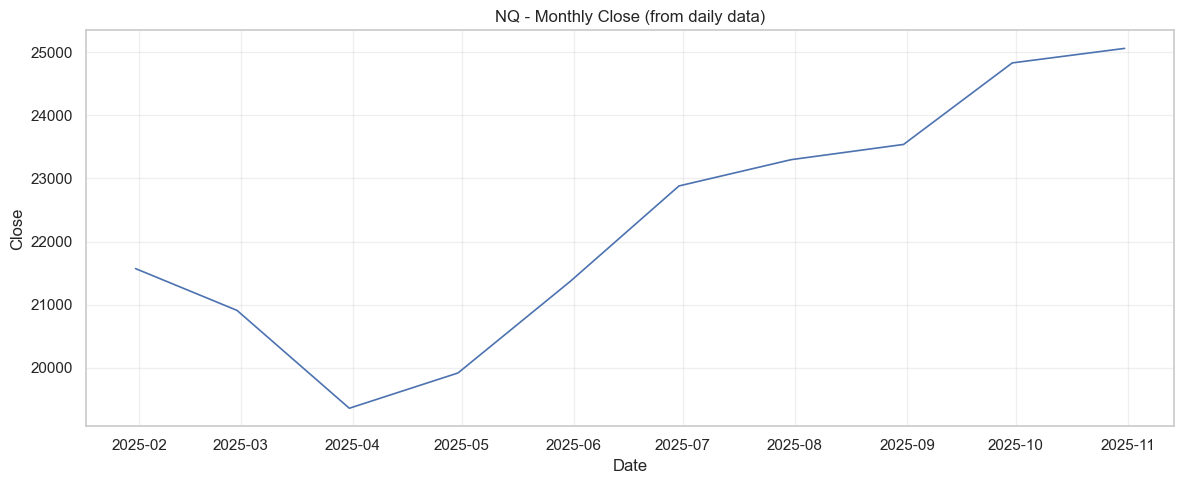

In [18]:
df_plot = df_nq_daily.copy()
df_plot["datetime"] = pd.to_datetime(df_plot["datetime"], errors="coerce")
df_plot = df_plot.dropna(subset=["datetime"]).sort_values("datetime").set_index("datetime")

monthly_close = df_plot["close"].resample("ME").last()

plt.figure(figsize=(12, 5))
plt.plot(monthly_close.index, monthly_close.values, linewidth=1.2)
plt.title("NQ - Monthly Close (from daily data)")
plt.xlabel("Date")
plt.ylabel("Close")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


**Taak (concreet):** Gebruik `df_nq_daily` om een duidelijke tijdreeks-grafiek te maken met **seaborn**, waarbij de dagelijkse data wordt geaggregeerd naar **maandelijkse** `close` (laatste koers van de maand) voor een leesbare lijnplot.

In [19]:
import seaborn as sns

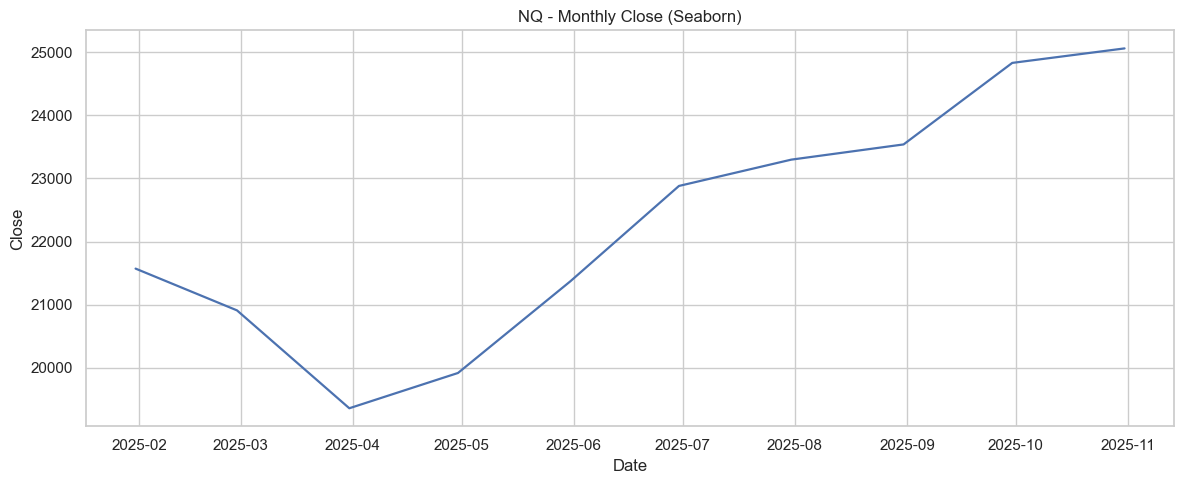

In [20]:
import pandas as pd
import matplotlib.pyplot as plt

df_sb = df_nq_daily.copy()
df_sb["datetime"] = pd.to_datetime(df_sb["datetime"], errors="coerce")
df_sb = df_sb.dropna(subset=["datetime"]).sort_values("datetime").set_index("datetime")

monthly_close_sb = df_sb["close"].resample("ME").last().reset_index(name="close")

sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 5))
ax = sns.lineplot(data=monthly_close_sb, x="datetime", y="close", linewidth=1.6)
ax.set_title("NQ - Monthly Close (Seaborn)")
ax.set_xlabel("Date")
ax.set_ylabel("Close")
plt.tight_layout()
plt.show()


**Taak (gespecificeerd):** Gebruik `df_nq_daily` om een **candlestick chart** te tekenen (OHLC), met **seaborn styling** (`sns.set_theme`) en een **beperkt aantal recente candles** (bv. laatste 200 handelsdagen) voor leesbaarheid.

In [21]:
df_cs = df_nq_daily.copy()
df_cs["datetime"] = pd.to_datetime(df_cs["datetime"], errors="coerce")
df_cs = df_cs.dropna(subset=["datetime"]).sort_values("datetime")

df_cs = df_cs[["datetime", "open", "high", "low", "close"]].dropna()
df_cs = df_cs.tail(50).reset_index(drop=True)

df_cs

,datetime,open,high,low,close
0,2025-10-09 13:30:00,25329.00,25334.75,25251.50,25278.75
1,2025-10-09 14:00:00,25279.50,25288.75,25244.25,25251.75
2,2025-10-09 14:30:00,25252.25,25260.00,25193.50,25250.50
3,2025-10-09 15:00:00,25251.50,25273.75,25222.75,25227.50
4,2025-10-09 15:30:00,25227.50,25274.50,25197.75,25263.00
5,2025-10-09 16:00:00,25263.25,25274.00,25234.75,25255.00
6,2025-10-09 16:30:00,25254.75,25261.50,25196.00,25203.75
7,2025-10-09 17:00:00,25204.25,25233.75,25169.75,25176.00
8,2025-10-09 17:30:00,25176.00,25218.25,25160.75,25215.50
9,2025-10-09 18:00:00,25215.50,25234.50,25182.50,25213.00


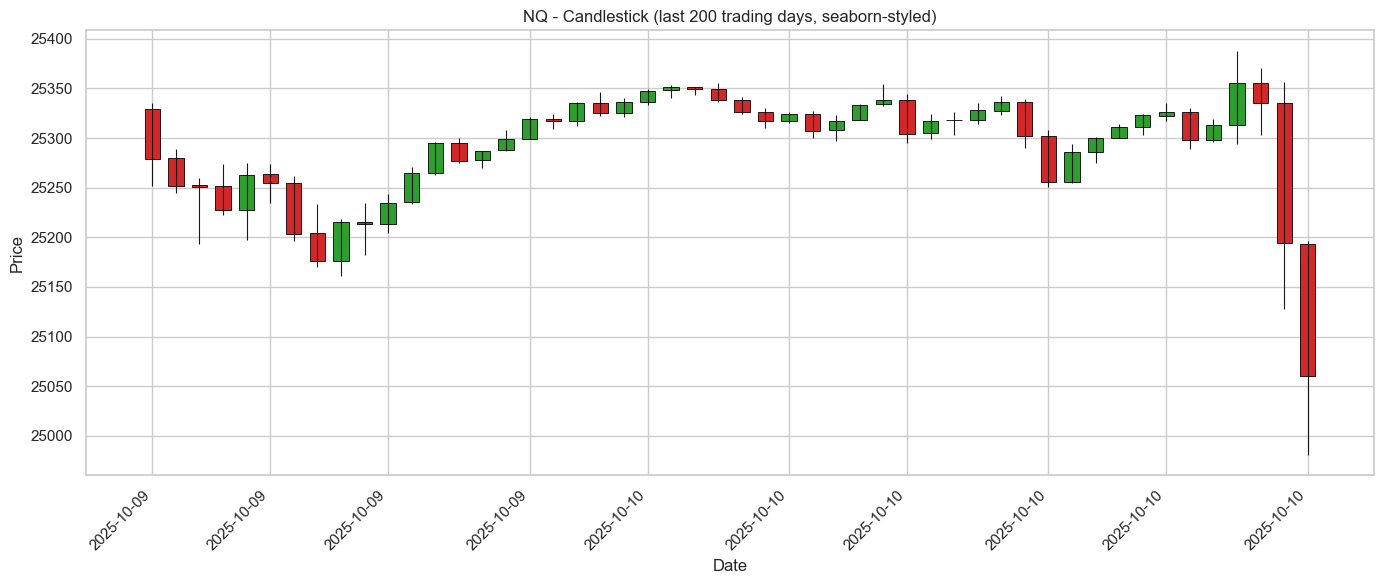

In [22]:
import numpy as np

sns.set_theme(style="whitegrid")

x = np.arange(len(df_cs))
o = df_cs["open"].to_numpy()
h = df_cs["high"].to_numpy()
l = df_cs["low"].to_numpy()
c = df_cs["close"].to_numpy()

up = c >= o
down = ~up

fig, ax = plt.subplots(figsize=(14, 6))

ax.vlines(x, l, h, color="black", linewidth=0.8, alpha=0.9)

body_w = 0.65
ax.bar(x[up], (c - o)[up], bottom=o[up], width=body_w, color="#2ca02c", edgecolor="black", linewidth=0.6)
ax.bar(x[down], (c - o)[down], bottom=o[down], width=body_w, color="#d62728", edgecolor="black", linewidth=0.6)

tick_n = min(10, len(df_cs))
tick_idx = np.linspace(0, len(df_cs) - 1, tick_n, dtype=int)
ax.set_xticks(tick_idx)
ax.set_xticklabels(df_cs["datetime"].iloc[tick_idx].dt.strftime("%Y-%m-%d"), rotation=45, ha="right")

ax.set_title("NQ - Candlestick (last 200 trading days, seaborn-styled)")
ax.set_xlabel("Date")
ax.set_ylabel("Price")
plt.tight_layout()
plt.show()


**Taak (gespecificeerd):** Gebruik `df_nq_daily` om een interactieve Plotly **candlestick (OHLC)** chart te tonen op basis van `datetime`, met een **beperkt aantal recente candles** (bv. laatste 200 handelsdagen) voor leesbaarheid en plot ook de moving average

In [23]:
import plotly.graph_objects as go

df_ply = df_nq_daily.copy()
df_ply["datetime"] = pd.to_datetime(df_ply["datetime"], errors="coerce")
df_ply = (
    df_ply.dropna(subset=["datetime"])
    .sort_values("datetime")
    [["datetime", "open", "high", "low", "close"]]
    .dropna()
    .tail(1000)
)

fig = go.Figure(
    data=[
        go.Candlestick(
            x=df_ply["datetime"],
            open=df_ply["open"],
            high=df_ply["high"],
            low=df_ply["low"],
            close=df_ply["close"],
            name="NQ",
        )
    ]
)

fig.update_layout(
    title="NQ - Candlestick (last 200 trading days)",
    xaxis_title="Date",
    yaxis_title="Price",
    xaxis_rangeslider_visible=False,
    template="plotly_white",
    height=550,
)

fig.show()


### Taak (concreet)
Gebruik `df_nq_daily` om een interactieve Plotly **candlestick (OHLC)** chart te tonen op basis van `datetime`, en plot daarbovenop de **50-daagse moving average** van `close` (SMA-50). Gebruik een beperkt aantal recente candles voor leesbaarheid.

In [24]:
import importlib

if importlib.util.find_spec("plotly") is None:
    !pip install plotly

In [25]:
import plotly.graph_objects as go

df_ma = df_nq_daily.copy()
df_ma["datetime"] = pd.to_datetime(df_ma["datetime"], errors="coerce")
df_ma = (
    df_ma.dropna(subset=["datetime"])
    .sort_values("datetime")
    [["datetime", "open", "high", "low", "close"]]
    .dropna()
)

df_ma["sma_50"] = df_ma["close"].rolling(50, min_periods=50).mean()

df_ma_plot = df_ma.tail(600)

fig = go.Figure()

fig.add_trace(
    go.Candlestick(
        x=df_ma_plot["datetime"],
        open=df_ma_plot["open"],
        high=df_ma_plot["high"],
        low=df_ma_plot["low"],
        close=df_ma_plot["close"],
        name="NQ",
    )
)

fig.add_trace(
    go.Scatter(
        x=df_ma_plot["datetime"],
        y=df_ma_plot["sma_50"],
        mode="lines",
        name="SMA 50",
        line=dict(width=2),
    )
)

fig.update_layout(
    title="NQ - Candlestick + SMA 50 (recent data)",
    xaxis_title="Date",
    yaxis_title="Price",
    xaxis_rangeslider_visible=False,
    template="plotly_white",
    height=600,
)

fig.show()
